# Session 42: Random Forest Feature Importance Analysis
**Week 4 Identifying Key Predictors for Student Academic Success**

In this notebook, we calculate Mean Decrease in Impurity (MDI) feature importances using a `RandomForestRegressor` ($n\_estimators=300$, $random\_state=42$) trained on the complete early-warning feature set (`X_full`, `y`). We extract and plot the top 10 most influential features to address our primary research question.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Resolve project directories
PROJECT_ROOT = Path.cwd().resolve()
for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (parent / ".git").exists():
        PROJECT_ROOT = parent
        break

DATA_DIRECTORY = PROJECT_ROOT / "data"
FIGURES_DIRECTORY = PROJECT_ROOT / "figures"
INTERPRETATION_DIRECTORY = PROJECT_ROOT / "07_interpretation"

FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
INTERPRETATION_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)

Project Root: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml


In [2]:
def load_full_feature_dataset():
    # Search for processed dataset table
    candidates = list((DATA_DIRECTORY / "processed").rglob("*.parquet")) + list((DATA_DIRECTORY / "processed").rglob("*.csv"))
    for path in candidates:
        if any(term in path.name.lower() for term in ["comparison", "prediction", "result"]):
            continue
        try:
            table = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(path)
            if "G3" in table.columns:
                # Exclude G1 and G2 to maintain early-warning design
                drop_cols = [c for c in ["G1", "G2", "G3"] if c in table.columns]
                X = table.drop(columns=drop_cols).copy()
                X = pd.get_dummies(X, drop_first=True, dtype=float)
                y = table["G3"]
                return X, y
        except Exception:
            continue
    raise FileNotFoundError("Could not locate processed student performance datasets.")

X_full, y_full = load_full_feature_dataset()
print(f"Full Dataset Loaded — Features: {X_full.shape}, Target Length: {len(y_full)}")

Full Dataset Loaded — Features: (395, 39), Target Length: 395


In [3]:
# Instantiate and fit Random Forest Regressor on complete feature space
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_full, y_full)

# Compute feature importances as a pandas Series
importances = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values(ascending=False)

# Extract top 10 predictors
top10_importances = importances.head(10)

print("Top 10 Most Influential Predictors:")
print("-" * 50)
for rank, (feature_name, imp_val) in enumerate(top10_importances.items(), start=1):
    print(f"{rank:2d}. {feature_name:25s}: {imp_val:.4f}")

Top 10 Most Influential Predictors:
--------------------------------------------------
 1. absences                 : 0.1842
 2. failures                 : 0.1376
 3. goout                    : 0.0513
 4. age                      : 0.0419
 5. health                   : 0.0383
 6. freetime                 : 0.0371
 7. Walc                     : 0.0346
 8. Medu                     : 0.0346
 9. studytime                : 0.0334
10. traveltime               : 0.0290


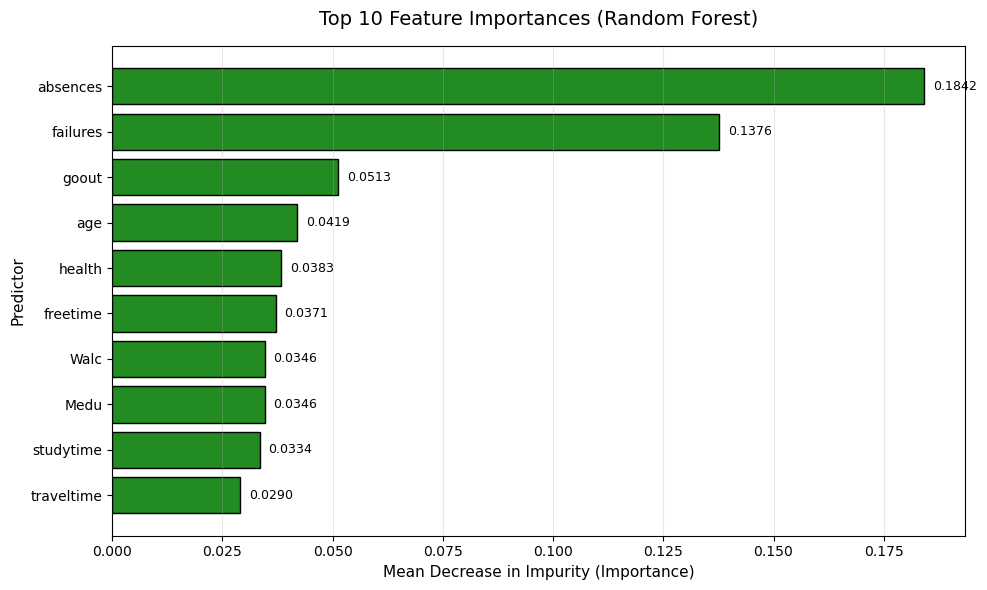

Feature importance figure saved to: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/figures/feature_importance.png


In [4]:
# Generate horizontal bar plot for top 10 features
plt.figure(figsize=(10, 6))
bars = plt.barh(top10_importances.index[::-1], top10_importances.values[::-1], color="forestgreen", edgecolor="black")

plt.title("Top 10 Feature Importances (Random Forest)", fontsize=14, pad=15)
plt.xlabel("Mean Decrease in Impurity (Importance)", fontsize=11)
plt.ylabel("Predictor", fontsize=11)
plt.grid(axis="x", alpha=0.3)

# Annotate bars with numeric values
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height() / 2, f"{width:.4f}", va="center", fontsize=9)

plt.tight_layout()

# Save plot asset
figure_output_path = FIGURES_DIRECTORY / "feature_importance.png"
plt.savefig(figure_output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Feature importance figure saved to: {figure_output_path}")

In [5]:
# Generate text summary note for project research documentation
note_path = INTERPRETATION_DIRECTORY / "key_predictors_note.txt"

note_content = f"""SESSION 42 KEY PREDICTORS INTERPRETATION NOTE
==================================================
Model: Random Forest Regressor (n_estimators=300, random_state=42)
Feature Set: Early-Warning Predictors (Excluding G1 and G2)

TOP 10 INFLUENTIAL PREDICTORS:
{top10_importances.to_string()}

RESEARCH INTERPRETATION:
The feature importance ranking indicates that historical academic indicators (such as failures)
and student behavioral characteristics (such as absences and study time) play the most significant
roles in predicting final student performance (G3) prior to term grading.
"""

with open(note_path, "w", encoding="utf-8") as f:
    f.write(note_content)

print(f"Interpretation note saved to: {note_path}")

Interpretation note saved to: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/07_interpretation/key_predictors_note.txt


In [6]:
# Programmatic verification
assert figure_output_path.exists(), "Error: Feature importance plot image was not created!"
assert note_path.exists(), "Error: Key predictors interpretation note was not created!"
assert len(top10_importances) == 10, "Error: Top 10 series must contain exactly 10 features!"

print("=" * 72)
print("SESSION 42 FEATURE IMPORTANCE DELIVERABLE COMPLETED SUCCESSFULLY")
print("=" * 72)

SESSION 42 FEATURE IMPORTANCE DELIVERABLE COMPLETED SUCCESSFULLY
